## PART A — Neural Network Foundations
 ## Task 1: Single Neuron Model

In [1]:
import math

# Sigmoid activation function
def sigmoid(z):
    return 1 / (1 + math.exp(-z))

# Single neuron function
def single_neuron(x, w, b):
    z = w * x + b
    y = sigmoid(z)
    return y

# Weight and bias
weight = 0.8
bias = -0.2

# Test inputs
inputs = [-2, -1, 0, 1, 2]

# Print outputs
for x in inputs:
    output = single_neuron(x, weight, bias)
    print(f"Input: {x}, Output: {output:.4f}")


Input: -2, Output: 0.1419
Input: -1, Output: 0.2689
Input: 0, Output: 0.4502
Input: 1, Output: 0.6457
Input: 2, Output: 0.8022


### Why do we need activation functions?

Activation functions help a neuron **decide what to “fire”** based on the input.  
Without them, the neuron would just do simple math (like adding and multiplying) and could only learn straight-line patterns.  
With activation functions, the neuron can learn **more complex patterns**, like curves or shapes, which makes neural networks much smarter.


## Task 2: Activation Functions

In [2]:
import math

# --- Sigmoid Function ---
def sigmoid(x):
    return 1 / (1 + math.exp(-x))

# Derivative of Sigmoid
def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

# --- ReLU Function ---
def relu(x):
    return max(0, x)

# Derivative of ReLU
def relu_derivative(x):
    return 1 if x > 0 else 0

# Sample inputs
inputs = [-2, -1, 0, 1, 2]

print("Sigmoid and its derivative:")
for x in inputs:
    print(f"x={x}, sigmoid={sigmoid(x):.4f}, derivative={sigmoid_derivative(x):.4f}")

print("\nReLU and its derivative:")
for x in inputs:
    print(f"x={x}, ReLU={relu(x):.4f}, derivative={relu_derivative(x):.4f}")


Sigmoid and its derivative:
x=-2, sigmoid=0.1192, derivative=0.1050
x=-1, sigmoid=0.2689, derivative=0.1966
x=0, sigmoid=0.5000, derivative=0.2500
x=1, sigmoid=0.7311, derivative=0.1966
x=2, sigmoid=0.8808, derivative=0.1050

ReLU and its derivative:
x=-2, ReLU=0.0000, derivative=0.0000
x=-1, ReLU=0.0000, derivative=0.0000
x=0, ReLU=0.0000, derivative=0.0000
x=1, ReLU=1.0000, derivative=1.0000
x=2, ReLU=2.0000, derivative=1.0000


## PART B — ANN from Scratch (Core)
## Task 3: Build a 2-Layer ANN

In [3]:
import numpy as np

# --- Activation functions ---
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# --- Binary Cross-Entropy Loss ---
def binary_cross_entropy(y_true, y_pred):
    # Add small epsilon to avoid log(0)
    epsilon = 1e-8
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    loss = - (y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return np.mean(loss)

# --- ANN Architecture ---
input_size = 2      # number of features
hidden_size = 3     # number of neurons in hidden layer
output_size = 1     # binary output

# --- Weight initialization (small random numbers) ---
np.random.seed(42)  # for reproducibility
W1 = np.random.randn(input_size, hidden_size) * 0.1
b1 = np.zeros(hidden_size)

W2 = np.random.randn(hidden_size, output_size) * 0.1
b2 = np.zeros(output_size)

# --- Sample input and true output ---
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])   # 4 samples, 2 features each

y_true = np.array([[0], [1], [1], [0]])  # XOR labels

# --- Forward Pass ---
# Hidden layer
Z1 = X.dot(W1) + b1
A1 = sigmoid(Z1)

# Output layer
Z2 = A1.dot(W2) + b2
y_pred = sigmoid(Z2)

# --- Compute Loss ---
loss = binary_cross_entropy(y_true, y_pred)

print("Predicted outputs:\n", y_pred)
print("\nBinary Cross-Entropy Loss:", loss)


Predicted outputs:
 [[0.52344745]
 [0.52490078]
 [0.5236808 ]
 [0.52513029]]

Binary Cross-Entropy Loss: 0.694327764185177


## Task 4: Backpropagation

In [4]:
import numpy as np

# --- Activation functions ---
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

# --- Binary Cross-Entropy Loss ---
def binary_cross_entropy(y_true, y_pred):
    epsilon = 1e-8
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    loss = - (y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return np.mean(loss)

# --- ANN Architecture ---
input_size = 2
hidden_size = 3
output_size = 1
learning_rate = 0.5
epochs = 1000

# --- Weight initialization ---
np.random.seed(42)
W1 = np.random.randn(input_size, hidden_size) * 0.1
b1 = np.zeros(hidden_size)
W2 = np.random.randn(hidden_size, output_size) * 0.1
b2 = np.zeros(output_size)

# --- Sample dataset (XOR) ---
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y_true = np.array([[0],[1],[1],[0]])

# --- Training Loop ---
for epoch in range(epochs):
    # --- Forward Pass ---
    Z1 = X.dot(W1) + b1
    A1 = sigmoid(Z1)
    Z2 = A1.dot(W2) + b2
    y_pred = sigmoid(Z2)
    
    # --- Compute Loss ---
    loss = binary_cross_entropy(y_true, y_pred)
    
    # --- Backpropagation ---
    # Output layer gradients
    dZ2 = y_pred - y_true               # derivative of loss w.r.t Z2
    dW2 = A1.T.dot(dZ2) / X.shape[0]   # weight gradient
    db2 = np.mean(dZ2, axis=0)         # bias gradient
    
    # Hidden layer gradients
    dA1 = dZ2.dot(W2.T)
    dZ1 = dA1 * sigmoid_derivative(Z1)
    dW1 = X.T.dot(dZ1) / X.shape[0]
    db1 = np.mean(dZ1, axis=0)
    
    # --- Update parameters ---
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    
    # --- Print loss every 100 epochs ---
    if (epoch+1) % 100 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

# --- Final predictions ---
print("\nFinal predicted outputs:\n", y_pred)
print("\nFinal weights W1:\n", W1)
print("\nFinal weights W2:\n", W2)


Epoch 100, Loss: 0.6931
Epoch 200, Loss: 0.6931
Epoch 300, Loss: 0.6931
Epoch 400, Loss: 0.6931
Epoch 500, Loss: 0.6931
Epoch 600, Loss: 0.6931
Epoch 700, Loss: 0.6931
Epoch 800, Loss: 0.6931
Epoch 900, Loss: 0.6931
Epoch 1000, Loss: 0.6931

Final predicted outputs:
 [[0.49925518]
 [0.50054449]
 [0.49946542]
 [0.50074937]]

Final weights W1:
 [[ 0.06947301 -0.01420324  0.06617636]
 [ 0.15714116 -0.02566052 -0.02052891]]

Final weights W2:
 [[ 0.12999546]
 [ 0.05008437]
 [-0.07479825]]


## Task 5: Training & Convergence

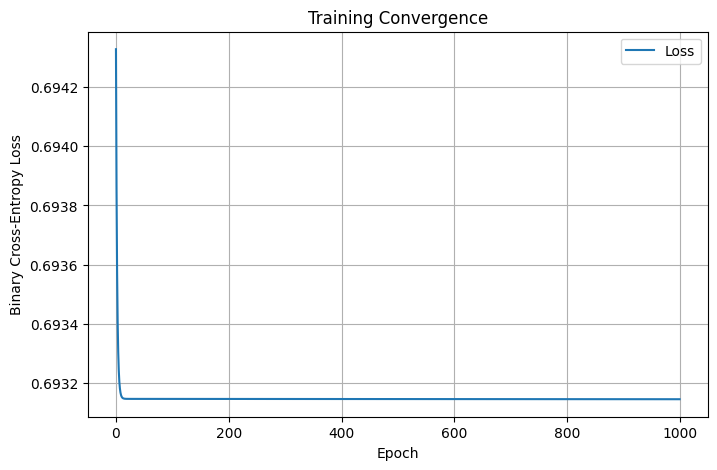

Final predictions:
 [[0.49925518]
 [0.50054449]
 [0.49946542]
 [0.50074937]]


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- Activation functions ---
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

# --- Binary Cross-Entropy Loss ---
def binary_cross_entropy(y_true, y_pred):
    epsilon = 1e-8
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    loss = - (y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return np.mean(loss)

# --- ANN Architecture ---
input_size = 2
hidden_size = 3
output_size = 1
learning_rate = 0.5
epochs = 1000

# --- Weight initialization ---
np.random.seed(42)
W1 = np.random.randn(input_size, hidden_size) * 0.1
b1 = np.zeros(hidden_size)
W2 = np.random.randn(hidden_size, output_size) * 0.1
b2 = np.zeros(output_size)

# --- Sample dataset (XOR) ---
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y_true = np.array([[0],[1],[1],[0]])

# --- Track loss ---
loss_history = []

# --- Training Loop ---
for epoch in range(epochs):
    # Forward Pass
    Z1 = X.dot(W1) + b1
    A1 = sigmoid(Z1)
    Z2 = A1.dot(W2) + b2
    y_pred = sigmoid(Z2)
    
    # Compute Loss
    loss = binary_cross_entropy(y_true, y_pred)
    loss_history.append(loss)
    
    # Backpropagation
    dZ2 = y_pred - y_true
    dW2 = A1.T.dot(dZ2) / X.shape[0]
    db2 = np.mean(dZ2, axis=0)
    
    dA1 = dZ2.dot(W2.T)
    dZ1 = dA1 * sigmoid_derivative(Z1)
    dW1 = X.T.dot(dZ1) / X.shape[0]
    db1 = np.mean(dZ1, axis=0)
    
    # Update parameters
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

# --- Plot Loss vs Epoch ---
plt.figure(figsize=(8,5))
plt.plot(loss_history, label='Loss')
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Training Convergence")
plt.legend()
plt.grid(True)
plt.show()

# --- Final predictions ---
print("Final predictions:\n", y_pred)
